In [1]:
from typing import List, Optional, TypedDict, Union
from enum import Enum

from langchain import hub
from langchain.chat_models import init_chat_model
from langchain_core.pydantic_v1 import Field
from langgraph.graph import END, START, StateGraph

from matcher.models.scorecard import (
    CriteriaType,
    ImportanceLevel,
    ImportantCriterion,
    MustHaveCriterion,
    NiceToHaveCriterion,
    Scorecard,
)


class Action(str, Enum):
    DELETE = "delete"
    ADD = "add"


class Action(TypedDict):
    action: Action = Field(..., description="The action to take (DELETE or ADD)")
    importance: ImportanceLevel = Field(
        ...,
        description="The importance level of the criterion (MUST_HAVE, IMPORTANT, NICE_TO_HAVE)",
    )
    type: CriteriaType = Field(
        ...,
        description="The type of criterion to add (EDUCATION, EXPERIENCE, LANGUAGE, HARD_SKILL, SOFT_SKILL, INDUSTRY_KNOWLEDGE, ADDITIONAL_QUALIFICATION)",
    )
    description: str = Field(..., description="The description of the criterion to add")


class JudgeOutput(TypedDict):
    is_valid: bool
    actions: List[Action] | None


class GraphState(TypedDict):
    raw_job_posting: str = Field(
        ..., description="The raw job posting to generate a scorecard for"
    )
    scorecard: Optional[Scorecard] = Field(description="The generated scorecard")
    actions: Optional[List[Action]] = Field(description="The actions to take")
    is_valid: Optional[bool] = Field(description="Whether the scorecard is valid")


# Define the nodes
def generate_scorecard(state: GraphState) -> GraphState:
    model = init_chat_model(
        model="claude-3-5-sonnet-20240620",
        model_provider="anthropic",
        temperature=0,
    )
    structured_model = model.with_structured_output(Scorecard)
    prompt = hub.pull("parser-scorecard")

    chain = prompt | structured_model
    output: Scorecard = chain.invoke(state["raw_job_posting"])

    return {"scorecard": output}


def judge_scorecard(state: GraphState) -> GraphState:
    model = init_chat_model(
        model="claude-3-5-sonnet-20240620",
        model_provider="anthropic",
        temperature=0,
    )
    structured_model = model.with_structured_output(JudgeOutput)
    prompt = hub.pull("judge-scorecard")

    chain = prompt | structured_model
    output: JudgeOutput = chain.invoke(state["scorecard"])

    return output


def apply_replacements(state: GraphState) -> GraphState:
    scorecard: Scorecard = state["scorecard"]
    actions: List[Action] = state["actions"]

    for action in actions:
        if action["action"] == Action.ADD:
            new_criterion = create_criterion(action)

            if action["importance"] == ImportanceLevel.MUST_HAVE:
                scorecard.mustHaveCriteria.criteria.append(new_criterion)
            elif action["importance"] == ImportanceLevel.IMPORTANT:
                scorecard.importantCriteria.criteria.append(new_criterion)
            elif action["importance"] == ImportanceLevel.NICE_TO_HAVE:
                scorecard.niceToHaveCriteria.criteria.append(new_criterion)

        elif action["action"] == Action.DELETE:
            if action["importance"] == ImportanceLevel.MUST_HAVE:
                scorecard.mustHaveCriteria.criteria = [
                    c
                    for c in scorecard.mustHaveCriteria.criteria
                    if c.description != action["description"]
                ]
            elif action["importance"] == ImportanceLevel.IMPORTANT:
                scorecard.importantCriteria.criteria = [
                    c
                    for c in scorecard.importantCriteria.criteria
                    if c.description != action["description"]
                ]
            elif action["importance"] == ImportanceLevel.NICE_TO_HAVE:
                scorecard.niceToHaveCriteria.criteria = [
                    c
                    for c in scorecard.niceToHaveCriteria.criteria
                    if c.description != action["description"]
                ]

    recalculate_weights(scorecard.mustHaveCriteria.criteria)
    recalculate_weights(scorecard.importantCriteria.criteria)

    return {"scorecard": scorecard}


def create_criterion(
    action: Action,
) -> Union[MustHaveCriterion, ImportantCriterion, NiceToHaveCriterion]:
    base_criterion = {
        "description": action["description"],
        "type": action["type"],
        "importance": action["importance"],
    }

    if action["importance"] == ImportanceLevel.MUST_HAVE:
        return MustHaveCriterion(**base_criterion, weight=0.0)
    elif action["importance"] == ImportanceLevel.IMPORTANT:
        return ImportantCriterion(**base_criterion, weight=0.0)
    elif action["importance"] == ImportanceLevel.NICE_TO_HAVE:
        return NiceToHaveCriterion(**base_criterion, maxBonusPoint=1.0)


def recalculate_weights(criteria: List[Union[MustHaveCriterion, ImportantCriterion]]):
    total_criteria = len(criteria)
    if total_criteria > 0:
        new_weight = 1.0 / total_criteria
        for criterion in criteria:
            criterion.weight = new_weight

In [2]:

# Define the graph
workflow = StateGraph(GraphState)

# Add nodes to the graph
workflow.add_node("generate_scorecard", generate_scorecard)
workflow.add_node("judge_scorecard", judge_scorecard)
workflow.add_node("apply_replacements", apply_replacements)

# Define the edges using add_conditional_edge
workflow.add_edge(START, "generate_scorecard")
workflow.add_edge("generate_scorecard", "judge_scorecard")

workflow.add_conditional_edges(
    "judge_scorecard",
    lambda x: x["is_valid"],
    {True: END, False: "apply_replacements"},
)

workflow.add_edge("apply_replacements", "judge_scorecard")

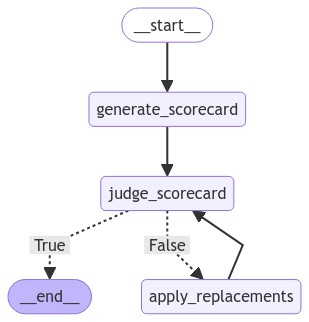

In [3]:
# Compile the graph
app = workflow.compile()

from IPython.display import Image, display
display(Image(app.get_graph(xray=1).draw_mermaid_png()))

In [4]:
job_posting_data = open("./ikola-joboffer.txt", "r").read()
job_posting_data

'IKOULA\nChargé de communication (h/f) en CDI à Reims\nCDI\nBezannes\nSalaire :\nNon spécifié\nTélétravail fréquent\nPostuler\n\nSauvegarder\nil y a 10 heures\n\n\nPartager\n\nIKOULA\nIKOULA\nCette offre vous tente ?\nPostuler\n\nSauvegarder\nQuestions et réponses sur l\'offre\n\nLe télétravail est-il possible pour ce poste ?\n\nQuel est le type de contrat pour ce poste ?\nLe poste\nDescriptif du poste\nEn tant que Chargé de Communication au sein d\'une équipe de 4 personnes, vous travaillerez sous la responsabilité de la Responsable Marketing et Communication.\n\nVous aurez la responsabilité de : \n\nLa communication interne :\nGérer l’intranet (articles Sharepoint / proposition de contenu interne...)\nAnimer des challenges internes et l\'évènementiel interne\nAnimer une démarche RSE au quotidien\n \n\nLa communication externe :\nSuivre les réseaux sociaux : réponses aux posts, suivi des plannings des publications, animations type challenges et concours, veille...\nAnimer l’évènementi

In [5]:

# Run the graph
initial_state: GraphState = {
    "raw_job_posting": job_posting_data,
    "scorecard": None,
    "actions": None,
    "is_valid": None,
}
result = app.invoke(initial_state)
result

/var/folders/yg/fy_zcpb50_q5cphjxd4w9f3h0000gn/T/ipykernel_10973/1861852750.py:53: LangChainBetaWarning: The function `init_chat_model` is in beta. It is actively being worked on, so the API may change.
  model = init_chat_model(
/Users/aberman/Documents/Workshop/repio-intelligence/.venv/lib/python3.12/site-packages/langsmith/client.py:5434: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  prompt = loads(json.dumps(prompt_object.manifest))


{'is_valid': True, 'actions': 'null'}